# **1. Perkenalan Dataset**

**Sumber dataset**: Kaggle, *Credit Score Classification* oleh Paris Rohan (`parisrohan/credit-score-classification`).

**Isi dataset**: berkas `train.csv` berisi 100.000 baris dan 28 kolom. Data mencakup sekitar 12.500 nasabah dengan 8 catatan bulanan per nasabah (Januari sampai Agustus). Berkas `test.csv` tidak memiliki kolom target, sehingga tidak dipakai. Pembagian data latih dan uji dibuat sendiri pada tahap preprocessing.

**Target**: `Credit_Score` dengan tiga kelas, yaitu `Poor`, `Standard`, dan `Good`.

**Kelompok kolom**:
- Identitas: `ID`, `Customer_ID`, `Name`, `SSN`, `Month`
- Profil nasabah: `Age`, `Occupation`, `Annual_Income`, `Monthly_Inhand_Salary`
- Perbankan: `Num_Bank_Accounts`, `Num_Credit_Card`, `Interest_Rate`, `Num_of_Loan`, `Type_of_Loan`
- Perilaku pembayaran: `Delay_from_due_date`, `Num_of_Delayed_Payment`, `Changed_Credit_Limit`, `Num_Credit_Inquiries`, `Credit_Mix`, `Outstanding_Debt`, `Credit_Utilization_Ratio`, `Credit_History_Age`, `Payment_of_Min_Amount`, `Total_EMI_per_month`, `Amount_invested_monthly`, `Payment_Behaviour`, `Monthly_Balance`

Dataset ini merupakan data mentah yang sengaja "kotor": terdapat nilai placeholder (`_`, `_______`, `!@9#%8`), angka yang dibungkus garis bawah (misalnya `__10000__`), kolom numerik bertipe teks, umur dan jumlah rekening yang tidak masuk akal, serta nilai kosong. Tahap EDA dan preprocessing di bawah ini menangani hal-hal tersebut.

# **2. Import Library**

In [ ]:
import os
import re
import shutil
import subprocess
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# **3. Memuat Dataset**

Dataset diunduh dari Kaggle memakai `kagglehub`. jika upload dataset, unduh `train.csv` secara manual lalu isi `LOCAL_TRAIN_PATH` dengan lokasinya.

In [ ]:
KAGGLE_DATASET = "parisrohan/credit-score-classification"
LOCAL_TRAIN_PATH = None  # isi dengan path file train.csv
RAW_DIR = "creditscore_raw"


def find_train_csv():
    if LOCAL_TRAIN_PATH:
        return LOCAL_TRAIN_PATH
    try:
        import kagglehub
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub
    dataset_dir = kagglehub.dataset_download(KAGGLE_DATASET)
    for root, _, files in os.walk(dataset_dir):
        if "train.csv" in files:
            return os.path.join(root, "train.csv")
    raise FileNotFoundError("train.csv tidak ditemukan pada dataset Kaggle")


train_path_source = find_train_csv()

os.makedirs(RAW_DIR, exist_ok=True)
shutil.copy(train_path_source, os.path.join(RAW_DIR, "train.csv"))

df_raw = pd.read_csv(os.path.join(RAW_DIR, "train.csv"), low_memory=False)
print("Ukuran data mentah:", df_raw.shape)
df_raw.head()

Using Colab cache for faster access to the 'credit-score-classification' dataset.
Ukuran data mentah: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

### Fungsi bantu

Dua fungsi kecil berikut dipakai pada tahap EDA maupun preprocessing:
- `to_numeric_clean`: membuang garis bawah pada angka bertipe teks lalu mengubahnya menjadi numerik.
- `parse_history_age`: mengubah teks seperti `22 Years and 1 Months` menjadi jumlah bulan.

In [ ]:
def to_numeric_clean(series):
    cleaned = series.astype(str).str.strip().str.replace("_", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")


def parse_history_age(series):
    parts = series.astype(str).str.extract(r"(\d+)\s*Years?\s*and\s*(\d+)\s*Months?")
    return parts[0].astype(float) * 12 + parts[1].astype(float)

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan pemeriksaan tipe data, nilai kosong, nilai placeholder, struktur nasabah, distribusi target, distribusi fitur, dan anomali nilai numerik.

In [ ]:
TARGET = "Credit_Score"
TARGET_MAP = {"Poor": 0, "Standard": 1, "Good": 2}

NUMERIC_TEXT_COLS = [
    "Age", "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment",
    "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance",
]
NUM_COLS = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts", "Num_Credit_Card",
    "Interest_Rate", "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment",
    "Changed_Credit_Limit", "Num_Credit_Inquiries", "Outstanding_Debt",
    "Credit_Utilization_Ratio", "Credit_History_Age", "Total_EMI_per_month",
    "Amount_invested_monthly", "Monthly_Balance",
]
CAT_COLS = ["Occupation", "Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour"]

### 4.1 Tipe data dan nilai kosong

In [ ]:
overview = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(2),
    "unique": df_raw.nunique(),
})
overview

,dtype,missing,missing_%,unique
ID,object,0,0.00,100000
Customer_ID,object,0,0.00,12500
Month,object,0,0.00,8
Name,object,9985,9.98,10139
Age,object,0,0.00,1788
SSN,object,0,0.00,12501
Occupation,object,0,0.00,16
Annual_Income,object,0,0.00,18940
Monthly_Inhand_Salary,float64,15002,15.00,13235
Num_Bank_Accounts,int64,0,0.00,943


### 4.2 Nilai placeholder dan angka bergaris bawah

Beberapa kolom memakai nilai pengganti seperti `_`, `_______`, atau `!@9#%8` untuk data yang hilang. Kolom numerik yang bertipe teks juga memuat garis bawah, misalnya `__10000__`.

In [ ]:
PLACEHOLDERS = ["_", "_______", "!@9#%8", "NM"]

placeholder_counts = {}
for col in df_raw.select_dtypes(exclude="number").columns:
    n = int(df_raw[col].isin(PLACEHOLDERS).sum())
    if n:
        placeholder_counts[col] = n
print("Jumlah nilai placeholder per kolom:")
print(pd.Series(placeholder_counts, dtype=int))

underscore_counts = {
    col: int(df_raw[col].astype(str).str.contains("_", regex=False).sum())
    for col in NUMERIC_TEXT_COLS
}
print()
print("Jumlah nilai bergaris bawah pada kolom numerik bertipe teks:")
print(pd.Series(underscore_counts, dtype=int))

Jumlah nilai placeholder per kolom:
Occupation                7062
Changed_Credit_Limit      2091
Credit_Mix               20195
Payment_of_Min_Amount    12007
Payment_Behaviour         7600
dtype: int64

Jumlah nilai bergaris bawah pada kolom numerik bertipe teks:
Age                        4939
Annual_Income              6980
Num_of_Loan                4785
Num_of_Delayed_Payment     2744
Changed_Credit_Limit       2091
Outstanding_Debt           1009
Amount_invested_monthly    4305
Monthly_Balance               9
dtype: int64


### 4.3 Struktur nasabah

Setiap nasabah muncul beberapa kali (satu baris per bulan). Kolom seperti umur, pekerjaan, dan pendapatan tahunan seharusnya sama di semua bulan, sehingga perbedaan nilai antar bulan pada satu nasabah menandakan data yang rusak. Temuan ini dipakai untuk strategi perbaikan data pada tahap preprocessing.

In [ ]:
rows_per_customer = df_raw.groupby("Customer_ID").size()
print("Jumlah nasabah unik:", rows_per_customer.shape[0])
print(rows_per_customer.describe().round(2))

STATIC_COLS = ["Age", "Occupation", "Annual_Income", "Num_Bank_Accounts",
               "Num_Credit_Card", "Interest_Rate", "Num_of_Loan"]
unique_per_customer = df_raw.groupby("Customer_ID")[STATIC_COLS].nunique()
print()
print("Proporsi nasabah dengan lebih dari satu nilai berbeda antar bulan:")
print((unique_per_customer > 1).mean().round(3))

Jumlah nasabah unik: 12500
count    12500.0
mean         8.0
std          0.0
min          8.0
25%          8.0
50%          8.0
75%          8.0
max          8.0
dtype: float64

Proporsi nasabah dengan lebih dari satu nilai berbeda antar bulan:
Age                  0.774
Occupation           0.444
Annual_Income        0.482
Num_Bank_Accounts    0.122
Num_Credit_Card      0.190
Interest_Rate        0.153
Num_of_Loan          0.532
dtype: float64


### 4.4 Distribusi target

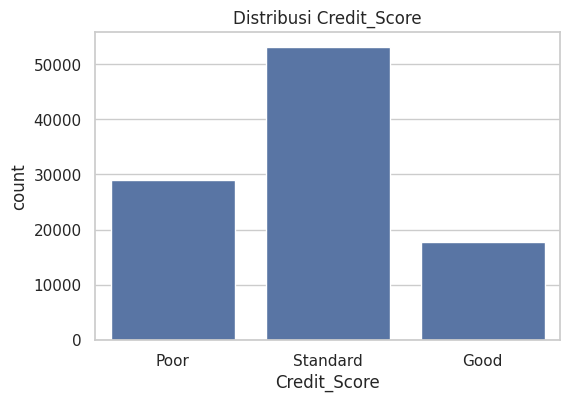

Credit_Score
Standard    0.532
Poor        0.290
Good        0.178
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
order = ["Poor", "Standard", "Good"]
sns.countplot(x=TARGET, data=df_raw, order=order)
plt.title("Distribusi Credit_Score")
plt.show()

print(df_raw[TARGET].value_counts(normalize=True).round(3))

### 4.5 Fitur kategorikal terhadap target

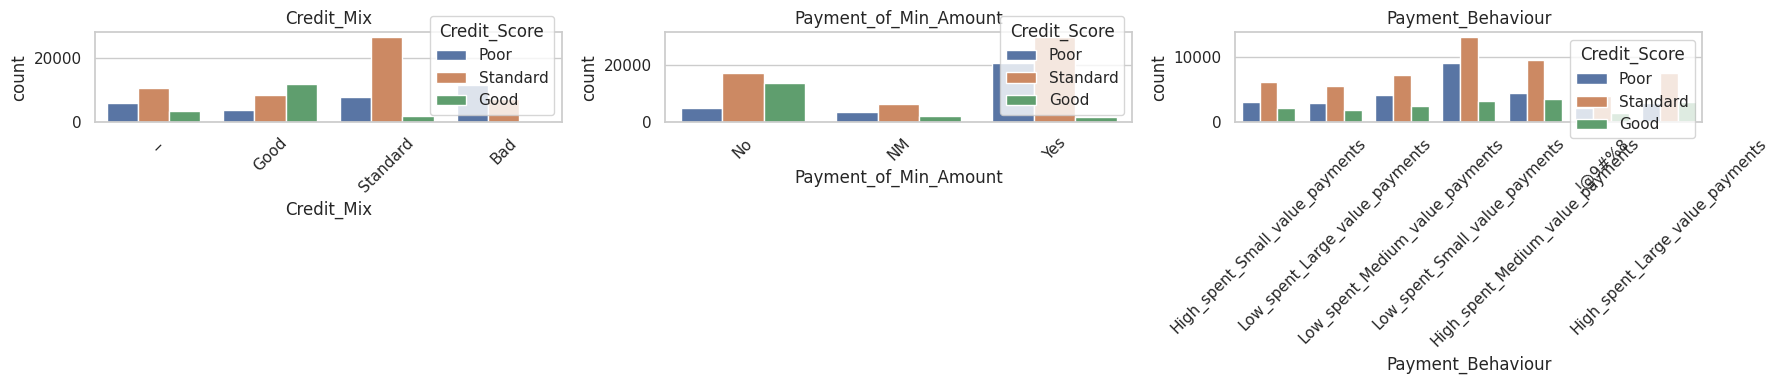

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ["Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour"]):
    sns.countplot(x=col, hue=TARGET, data=df_raw, hue_order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 4.6 Statistik dan anomali fitur numerik

Kolom bertipe teks dikonversi ke angka sementara (hanya untuk EDA) agar statistik deskriptifnya dapat dilihat.

In [ ]:
eda_num = pd.DataFrame({c: to_numeric_clean(df_raw[c]) for c in NUM_COLS if c != "Credit_History_Age"})
eda_num["Credit_History_Age"] = parse_history_age(df_raw["Credit_History_Age"])
eda_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Monthly_Inhand_Salary,84998.0,4.194171e+03,3.183686e+03,3.036454e+02,1625.568229,3093.745000,5957.448333,1.520463e+04
Num_Bank_Accounts,100000.0,1.709128e+01,1.174048e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,2.247443e+01,1.290574e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,7.246604e+01,4.664226e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,100000.0,2.106878e+01,1.486010e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97909.0,1.038903e+01,6.789496e+00,-6.490000e+00,5.320000,9.400000,14.870000,3.697000e+01


In [ ]:
anomalies = pd.Series({
    "Age di luar rentang 14-100": int(((eda_num["Age"] < 14) | (eda_num["Age"] > 100)).sum()),
    "Num_Bank_Accounts negatif": int((eda_num["Num_Bank_Accounts"] < 0).sum()),
    "Num_of_Loan negatif": int((eda_num["Num_of_Loan"] < 0).sum()),
    "Num_Credit_Card > 50": int((eda_num["Num_Credit_Card"] > 50).sum()),
    "Interest_Rate > 100": int((eda_num["Interest_Rate"] > 100).sum()),
    "Monthly_Balance ekstrem (|nilai| > 1 juta)": int((eda_num["Monthly_Balance"].abs() > 1e6).sum()),
})
print("Jumlah nilai tidak masuk akal:")
print(anomalies)

Jumlah nilai tidak masuk akal:
Age di luar rentang 14-100                    2776
Num_Bank_Accounts negatif                       21
Num_of_Loan negatif                           3876
Num_Credit_Card > 50                          2214
Interest_Rate > 100                           2012
Monthly_Balance ekstrem (|nilai| > 1 juta)       9
dtype: int64


# **5. Data Preprocessing**

Alur preprocessing, berdasarkan temuan EDA:

1. Menghapus kolom yang tidak dipakai sebagai fitur (`ID`, `Name`, `SSN`, `Month`, `Type_of_Loan`) dan mengubah target menjadi angka.
2. Membersihkan placeholder dan garis bawah, lalu mengonversi tipe data.
3. Menerapkan aturan domain (umur dan jumlah yang tidak masuk akal dijadikan kosong).
4. Memperbaiki dan mengisi nilai per nasabah, memanfaatkan 8 catatan bulanan tiap nasabah.
5. Membagi data menjadi train dan test **per nasabah**, sehingga satu nasabah tidak muncul di kedua sisi.
6. Mengisi sisa nilai kosong, menangani outlier, encoding, dan standarisasi, semuanya dengan statistik yang dihitung dari data train saja.

Perbaikan per nasabah (langkah 4) hanya memakai baris milik nasabah yang sama, sehingga tidak menimbulkan kebocoran data antara train dan test.

### 5.1 Menghapus kolom dan menyandikan target

`ID`, `Name`, dan `SSN` adalah identitas yang tidak bermakna bagi model. `Month` dibuang karena hanya penanda urutan catatan. `Type_of_Loan` berupa teks daftar dengan banyak kombinasi, sedangkan jumlah pinjaman sudah terwakili oleh `Num_of_Loan`. `Customer_ID` dipertahankan sementara untuk keperluan pengelompokan.

In [ ]:
df = df_raw.drop(columns=["ID", "Name", "SSN", "Month", "Type_of_Loan"]).copy()

df = df[df[TARGET].isin(TARGET_MAP)].copy()
df[TARGET] = df[TARGET].map(TARGET_MAP).astype(int)

print("Ukuran data:", df.shape)
print(df[TARGET].value_counts().sort_index())

Ukuran data: (100000, 23)
Credit_Score
0    28998
1    53174
2    17828
Name: count, dtype: int64


### 5.2 Membersihkan placeholder dan mengonversi tipe data

In [ ]:
PLACEHOLDER_MAP = {
    "Occupation": ["_______"],
    "Credit_Mix": ["_"],
    "Payment_Behaviour": ["!@9#%8"],
}
for col, bad_values in PLACEHOLDER_MAP.items():
    df[col] = df[col].replace(bad_values, np.nan)

for col in NUM_COLS:
    if col != "Credit_History_Age":
        df[col] = to_numeric_clean(df[col])
df["Credit_History_Age"] = parse_history_age(df["Credit_History_Age"])

print("Nilai kosong setelah pembersihan (kolom yang memiliki nilai kosong):")
missing_now = df.isna().sum()
print(missing_now[missing_now > 0])

Nilai kosong setelah pembersihan (kolom yang memiliki nilai kosong):
Occupation                  7062
Monthly_Inhand_Salary      15002
Num_of_Delayed_Payment      7002
Changed_Credit_Limit        2091
Num_Credit_Inquiries        1965
Credit_Mix                 20195
Credit_History_Age          9030
Amount_invested_monthly     4479
Payment_Behaviour           7600
Monthly_Balance             1200
dtype: int64


### 5.3 Aturan domain

Umur di luar 14-100 tahun dan jumlah rekening, kartu, atau pinjaman yang negatif tidak masuk akal, sehingga dijadikan kosong untuk diperbaiki pada langkah berikutnya.

In [ ]:
df.loc[~df["Age"].between(14, 100), "Age"] = np.nan
for col in ["Num_Bank_Accounts", "Num_Credit_Card", "Num_of_Loan"]:
    df.loc[df[col] < 0, col] = np.nan

print("Age kosong setelah aturan domain:", int(df["Age"].isna().sum()))

Age kosong setelah aturan domain: 2776


### 5.4 Memperbaiki dan mengisi nilai per nasabah

- **Kolom statis** (umur, pekerjaan, pendapatan tahunan, jumlah rekening, jumlah kartu, suku bunga, jumlah pinjaman) seharusnya konstan per nasabah, sehingga seluruh barisnya diganti dengan modus per nasabah. Cara ini memperbaiki nilai kosong sekaligus nilai yang rusak pada satu bulan.
- **Kolom dinamis** yang kosong diisi dengan median per nasabah (numerik) atau modus per nasabah (kategorikal).

In [ ]:
def customer_mode(series):
    modes = series.mode(dropna=True)
    return modes.iloc[0] if len(modes) else np.nan


for col in STATIC_COLS:
    df[col] = df.groupby("Customer_ID")[col].transform(customer_mode)

DYNAMIC_NUM_COLS = [
    "Monthly_Inhand_Salary", "Num_of_Delayed_Payment", "Changed_Credit_Limit",
    "Num_Credit_Inquiries", "Credit_History_Age", "Amount_invested_monthly", "Monthly_Balance",
]
for col in DYNAMIC_NUM_COLS:
    df[col] = df[col].fillna(df.groupby("Customer_ID")[col].transform("median"))

for col in ["Credit_Mix", "Payment_Behaviour"]:
    df[col] = df[col].fillna(df.groupby("Customer_ID")[col].transform(customer_mode))

print("Sisa nilai kosong setelah perbaikan per nasabah:")
missing_now = df.isna().sum()
print(missing_now[missing_now > 0] if (missing_now > 0).any() else "tidak ada")

Sisa nilai kosong setelah perbaikan per nasabah:
tidak ada


### 5.5 Membagi data train dan test per nasabah

Pembagian 80:20 memakai `StratifiedGroupKFold` sehingga proporsi kelas terjaga dan semua catatan satu nasabah masuk ke sisi yang sama.

In [ ]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(df, df[TARGET], groups=df["Customer_ID"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

overlap = set(train_df["Customer_ID"]) & set(test_df["Customer_ID"])
print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print("Nasabah yang muncul di train dan test sekaligus:", len(overlap))
print()
print("Proporsi kelas train:", train_df[TARGET].value_counts(normalize=True).sort_index().round(3).to_dict())
print("Proporsi kelas test :", test_df[TARGET].value_counts(normalize=True).sort_index().round(3).to_dict())

Train: (80000, 23) | Test: (20000, 23)
Nasabah yang muncul di train dan test sekaligus: 0

Proporsi kelas train: {0: 0.289, 1: 0.531, 2: 0.18}
Proporsi kelas test : {0: 0.293, 1: 0.536, 2: 0.172}


### 5.6 Mengisi sisa nilai kosong (statistik dari train)

In [ ]:
num_median = train_df[NUM_COLS].median()
cat_mode = train_df[CAT_COLS].mode().iloc[0]

for part in (train_df, test_df):
    part[NUM_COLS] = part[NUM_COLS].fillna(num_median)
    part[CAT_COLS] = part[CAT_COLS].fillna(cat_mode)

print("Sisa nilai kosong (train/test):",
      int(train_df.isna().sum().sum()), "/", int(test_df.isna().sum().sum()))

Sisa nilai kosong (train/test): 0 / 0


### 5.7 Menangani outlier (capping IQR)

Batas dihitung dari data train dengan pengali 3 x IQR (batas outlier ekstrem), agar hanya nilai yang benar-benar tidak wajar (misalnya `Monthly_Balance` bernilai puluhan digit) yang terpotong, sementara distribusi yang memang miring tidak ikut terdistorsi. Kolom dengan IQR nol dilewati.

In [ ]:
q1 = train_df[NUM_COLS].quantile(0.25)
q3 = train_df[NUM_COLS].quantile(0.75)
iqr = q3 - q1
clip_lower = (q1 - 3 * iqr).where(iqr > 0, -np.inf)
clip_upper = (q3 + 3 * iqr).where(iqr > 0, np.inf)


def count_outliers(frame):
    return ((frame[NUM_COLS] < clip_lower) | (frame[NUM_COLS] > clip_upper)).sum()


outlier_summary = pd.DataFrame({
    "train_sebelum": count_outliers(train_df),
    "test_sebelum": count_outliers(test_df),
})

for part in (train_df, test_df):
    part[NUM_COLS] = part[NUM_COLS].clip(lower=clip_lower, upper=clip_upper, axis=1)

outlier_summary["train_sesudah"] = count_outliers(train_df)
outlier_summary["test_sesudah"] = count_outliers(test_df)
outlier_summary[outlier_summary.sum(axis=1) > 0]

,train_sebelum,test_sebelum,train_sesudah,test_sesudah
Num_of_Delayed_Payment,589,147,0,0
Num_Credit_Inquiries,1286,363,0,0
Total_EMI_per_month,3466,804,0,0
Amount_invested_monthly,4973,1200,0,0
Monthly_Balance,1245,311,0,0


### 5.8 Encoding data kategorikal

- `Credit_Mix` bersifat berjenjang, sehingga di-encode ordinal: `Bad` = 0, `Standard` = 1, `Good` = 2.
- `Occupation`, `Payment_of_Min_Amount`, dan `Payment_Behaviour` di-encode dengan one-hot. Kolom data test disamakan dengan kolom data train.

In [ ]:
CREDIT_MIX_MAP = {"Bad": 0, "Standard": 1, "Good": 2}
ONEHOT_COLS = ["Occupation", "Payment_of_Min_Amount", "Payment_Behaviour"]

for part in (train_df, test_df):
    part["Credit_Mix"] = part["Credit_Mix"].map(CREDIT_MIX_MAP)

train_enc = pd.get_dummies(train_df.drop(columns=["Customer_ID"]), columns=ONEHOT_COLS, dtype=int)
test_enc = pd.get_dummies(test_df.drop(columns=["Customer_ID"]), columns=ONEHOT_COLS, dtype=int)

feature_columns = [c for c in train_enc.columns if c != TARGET]
train_enc = train_enc[feature_columns + [TARGET]]
test_enc = test_enc.reindex(columns=feature_columns + [TARGET], fill_value=0)

print("Jumlah fitur setelah encoding:", len(feature_columns))
print("Nilai kosong hasil encoding (train/test):",
      int(train_enc.isna().sum().sum()), "/", int(test_enc.isna().sum().sum()))

Jumlah fitur setelah encoding: 42
Nilai kosong hasil encoding (train/test): 0 / 0


### 5.9 Standarisasi fitur numerik

`StandardScaler` dilatih pada data train saja, lalu diterapkan ke data train dan test.

In [ ]:
scaler = StandardScaler().fit(train_enc[NUM_COLS])
train_enc[NUM_COLS] = scaler.transform(train_enc[NUM_COLS])
test_enc[NUM_COLS] = scaler.transform(test_enc[NUM_COLS])

train_enc[NUM_COLS].describe().T[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
Age,-0.0,1.0,-1.787,2.101
Annual_Income,0.0,1.0,-1.133,3.364
Monthly_Inhand_Salary,-0.0,1.0,-1.219,3.438
Num_Bank_Accounts,-0.0,1.0,-2.071,1.792
Num_Credit_Card,0.0,1.0,-2.674,2.646
Interest_Rate,-0.0,1.0,-1.552,2.236
Num_of_Loan,0.0,1.0,-1.453,2.234
Delay_from_due_date,0.0,1.0,-1.759,3.098
Num_of_Delayed_Payment,0.0,1.0,-2.422,4.605
Changed_Credit_Limit,-0.0,1.0,-2.504,3.830


### 5.10 Validasi akhir dan penyimpanan hasil preprocessing

Hasil disimpan ke folder `creditscore_preprocessing` sebagai masukan pelatihan model pada Kriteria 2. Objek `scaler`, batas outlier, dan daftar kolom disimpan juga agar data baru (misalnya saat inferensi) dapat diproses dengan cara yang sama.

In [ ]:
OUT_DIR = "creditscore_preprocessing"
os.makedirs(OUT_DIR, exist_ok=True)

train_path = os.path.join(OUT_DIR, "train_preprocessed.csv")
test_path = os.path.join(OUT_DIR, "test_preprocessed.csv")
train_enc.to_csv(train_path, index=False, float_format="%.6f")
test_enc.to_csv(test_path, index=False, float_format="%.6f")

joblib.dump({
    "num_cols": NUM_COLS,
    "num_median": num_median,
    "cat_mode": cat_mode,
    "clip_lower": clip_lower,
    "clip_upper": clip_upper,
    "credit_mix_map": CREDIT_MIX_MAP,
    "target_map": TARGET_MAP,
    "onehot_cols": ONEHOT_COLS,
    "feature_columns": feature_columns,
    "scaler": scaler,
}, os.path.join(OUT_DIR, "preprocessing_artifacts.joblib"))

# Baca ulang untuk memastikan berkas tersimpan dengan benar
train_check = pd.read_csv(train_path)
test_check = pd.read_csv(test_path)

print("Train preprocessed:", train_check.shape)
print("Test preprocessed :", test_check.shape)
print("Kolom train dan test sama:", list(train_check.columns) == list(test_check.columns))
print("Nilai kosong (train/test):", int(train_check.isna().sum().sum()), "/", int(test_check.isna().sum().sum()))
print("Semua kolom numerik:", all(pd.api.types.is_numeric_dtype(t) for t in train_check.dtypes))
print()
print("Distribusi target (train):")
print(train_check[TARGET].value_counts().sort_index())
train_check.head()

Train preprocessed: (80000, 43)
Test preprocessed : (20000, 43)
Kolom train dan test sama: True
Nilai kosong (train/test): 0 / 0
Semua kolom numerik: True

Distribusi target (train):
Credit_Score
0    23143
1    42464
2    14393
Name: count, dtype: int64


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Occupation_Accountant,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Credit_Score
0,-0.95409,-0.818365,-0.743778,-0.911945,-0.739324,-1.322459,0.185908,-1.219481,-0.958323,0.125465,-0.453974,2,-0.532638,-1.067786,0.441210,-0.518436,-0.635331,-0.426754,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,2
1,-0.95409,-0.818365,-0.743778,-0.911945,-0.739324,-1.322459,0.185908,-1.489308,-1.031523,0.125465,-0.453974,2,-0.532638,-0.067061,0.476344,-0.518436,-0.461434,-0.561371,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,2
2,-0.95409,-0.818365,-0.743778,-0.911945,-0.739324,-1.322459,0.185908,-1.219481,-0.958323,0.125465,-0.453974,2,-0.532638,-0.718721,0.461286,-0.518436,-0.629433,-0.336338,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,2
3,-0.95409,-0.818365,-0.743778,-0.911945,-0.739324,-1.322459,0.185908,-1.084568,-1.397521,-0.614900,-0.453974,2,-0.532638,-0.177852,0.471325,-0.518436,-0.088619,-0.856924,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,2
4,-0.95409,-0.818365,-0.743778,-0.911945,-0.739324,-1.322459,0.185908,-1.017111,-1.031523,0.125465,-0.453974,2,-0.532638,-1.463452,0.481363,-0.518436,-0.814419,-0.286677,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,2


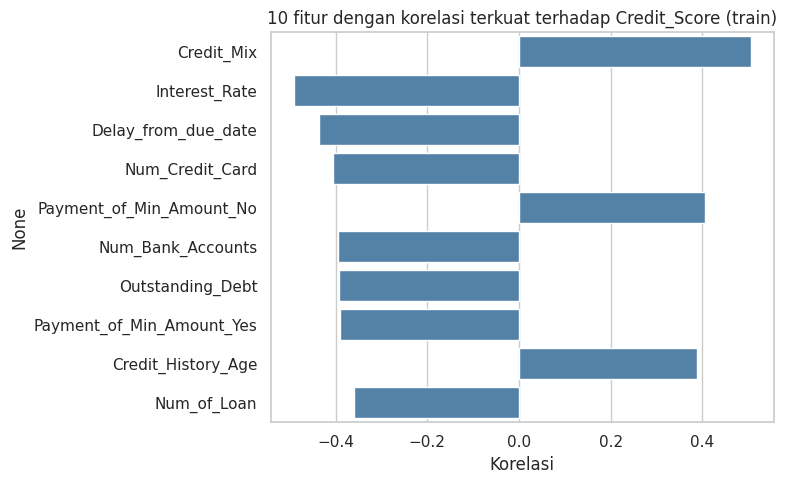

In [ ]:
corr_target = train_check.drop(columns=[TARGET]).corrwith(train_check[TARGET])
top_corr = corr_target.reindex(corr_target.abs().sort_values(ascending=False).head(10).index)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_corr.values, y=top_corr.index, color="steelblue")
plt.title("10 fitur dengan korelasi terkuat terhadap Credit_Score (train)")
plt.xlabel("Korelasi")
plt.tight_layout()
plt.show()

In [41]:
!zip -r creditscore_preprocessing.zip creditscore_preprocessing
!zip -r creditscore_raw.zip creditscore_raw

  adding: creditscore_preprocessing/ (stored 0%)
  adding: creditscore_preprocessing/train_preprocessed.csv (deflated 84%)
  adding: creditscore_preprocessing/test_preprocessed.csv (deflated 84%)
  adding: creditscore_preprocessing/preprocessing_artifacts.joblib (deflated 75%)
  adding: creditscore_raw/ (stored 0%)
  adding: creditscore_raw/train.csv (deflated 80%)
